In [1]:
from utils.data_loader import load_as_maps
from utils.model_analysis import get_masked_prediction_mlp, get_masked_prediction_map
from utils.plot_map import plot_maps_4x3_target_reconst_error
import numpy as np

/Users/<username>/Documents/CAU/Masterarbeit/master-thesis/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_ids = ["exp8"]
mlp_path = "../../outputs/mlp/best"
unet_path = "../../outputs/u-net/best"

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 282ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 294ms/step


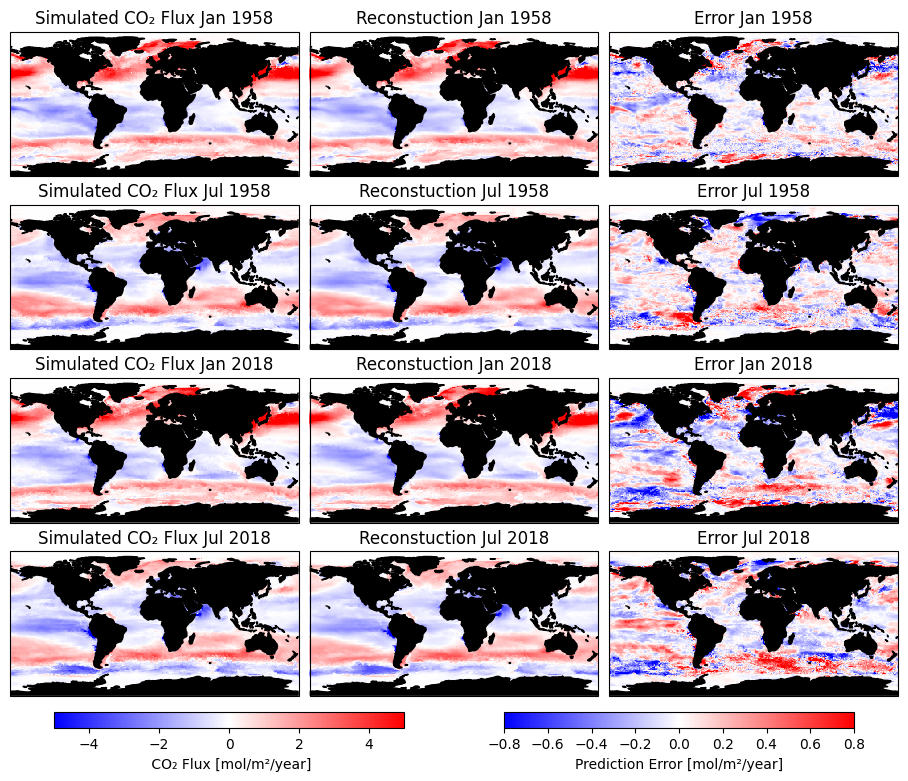

89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step


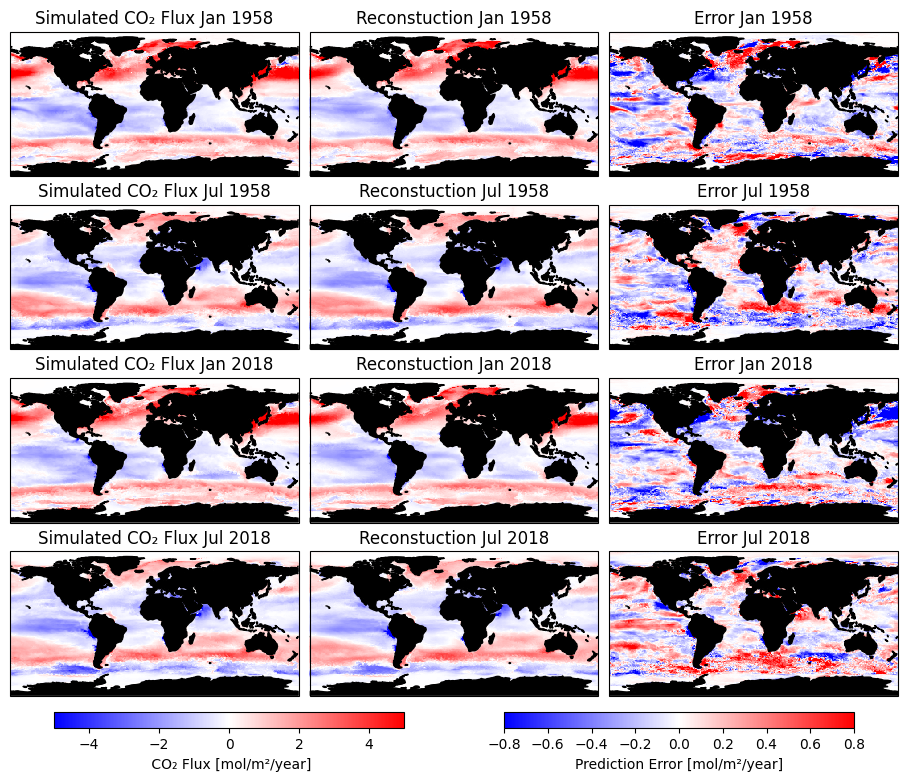

In [10]:
for dataset_id in dataset_ids:

    unet_data_dict = {}
    mlp_data_dict = {}

    targets_1958, unet_pred_1958 = get_masked_prediction_map(unet_path, dataset_id, start_year=1958, end_year=1958, target_index=3)
    unet_data_dict["Simulated CO₂ Flux Jan 1958"] = targets_1958[0]
    unet_data_dict["Reconstuction Jan 1958"] = unet_pred_1958[0]
    unet_data_dict["Error Jan 1958"] = unet_pred_1958[0]-targets_1958[0]

    unet_data_dict["Simulated CO₂ Flux Jul 1958"] = targets_1958[6]
    unet_data_dict["Reconstuction Jul 1958"] = unet_pred_1958[6]
    unet_data_dict["Error Jul 1958"] = unet_pred_1958[6]-targets_1958[6]

    targets_2018, unet_pred_2018 = get_masked_prediction_map(unet_path, dataset_id, start_year=2018, end_year=2018, target_index=3)
    unet_data_dict["Simulated CO₂ Flux Jan 2018"] = targets_2018[0]
    unet_data_dict["Reconstuction Jan 2018"] = unet_pred_2018[0]
    unet_data_dict["Error Jan 2018"] = unet_pred_2018[0]-targets_2018[0]

    unet_data_dict["Simulated CO₂ Flux Jul 2018"] = targets_2018[6]
    unet_data_dict["Reconstuction Jul 2018"] = unet_pred_2018[6]
    unet_data_dict["Error Jul 2018"] = unet_pred_2018[6]-targets_2018[6]

    plot_maps_4x3_target_reconst_error(
        unet_data_dict, 
        folder_path="../../outputs/plots/mixed_plots/", 
        file_name= dataset_id + "_unet_target_reconst_error",
        vmin1=-5, vmax1=5,
        vmin2=-0.8, vmax2=0.8
    )

    _, mlp_pred_1958 = get_masked_prediction_mlp(mlp_path, dataset_id, start_year=1958, end_year=1958, target_index=3)
    mlp_data_dict["Simulated CO₂ Flux Jan 1958"] = targets_1958[0]
    mlp_data_dict["Reconstuction Jan 1958"] = mlp_pred_1958[0]
    mlp_data_dict["Error Jan 1958"] = mlp_pred_1958[0]-targets_1958[0]

    mlp_data_dict["Simulated CO₂ Flux Jul 1958"] = targets_1958[6]
    mlp_data_dict["Reconstuction Jul 1958"] = mlp_pred_1958[6]
    mlp_data_dict["Error Jul 1958"] = mlp_pred_1958[6]-targets_1958[6]

    _, mlp_pred_2018 = get_masked_prediction_mlp(mlp_path, dataset_id, start_year=2018, end_year=2018, target_index=3)
    mlp_data_dict["Simulated CO₂ Flux Jan 2018"] = targets_2018[0]
    mlp_data_dict["Reconstuction Jan 2018"] = mlp_pred_2018[0]
    mlp_data_dict["Error Jan 2018"] = mlp_pred_2018[0]-targets_2018[0]

    mlp_data_dict["Simulated CO₂ Flux Jul 2018"] = targets_2018[6]
    mlp_data_dict["Reconstuction Jul 2018"] = mlp_pred_2018[6]
    mlp_data_dict["Error Jul 2018"] = mlp_pred_2018[6]-targets_2018[6]

    plot_maps_4x3_target_reconst_error(
        mlp_data_dict, 
        folder_path="../../outputs/plots/mixed_plots/", 
        file_name= dataset_id + "_mlp_target_reconst_error",
        vmin1=-5, vmax1=5,
        vmin2=-0.8, vmax2=0.8
    )
